<a href="https://colab.research.google.com/github/AdithyaBandari/Obesity-Risk-Classification-Using-ML-and-ANN/blob/main/obeisity_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel(r"/content/Obesity_Dataset (3).xlsx")
print(df)

      Sex  Age  Height  Overweight_Obese_Family  Consumption_of_Fast_Food  \
0       2   18     155                        2                         2   
1       2   18     158                        2                         2   
2       2   18     159                        2                         2   
3       2   18     162                        2                         2   
4       2   18     165                        2                         1   
...   ...  ...     ...                      ...                       ...   
1605    2   51     165                        2                         1   
1606    2   51     163                        2                         1   
1607    2   52     162                        1                         2   
1608    2   53     168                        2                         1   
1609    2   54     170                        1                         1   

      Frequency_of_Consuming_Vegetables  Number_of_Main_Meals_Daily  \
0   

In [3]:
df.head()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
0,2,18,155,2,2,3,1,3,2,1,2,3,3,4,2
1,2,18,158,2,2,3,1,1,2,1,2,1,3,3,2
2,2,18,159,2,2,2,1,3,2,3,2,2,3,4,2
3,2,18,162,2,2,2,2,2,2,2,2,1,3,4,2
4,2,18,165,2,1,2,1,3,2,1,2,3,3,2,2


In [4]:
df.columns

Index(['Sex', 'Age', 'Height', 'Overweight_Obese_Family',
       'Consumption_of_Fast_Food', 'Frequency_of_Consuming_Vegetables',
       'Number_of_Main_Meals_Daily', 'Food_Intake_Between_Meals', 'Smoking',
       'Liquid_Intake_Daily', 'Calculation_of_Calorie_Intake',
       'Physical_Excercise', 'Schedule_Dedicated_to_Technology',
       'Type_of_Transportation_Used', 'Class'],
      dtype='object')

In [5]:
df["Height"].max()

193

In [6]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of       Sex  Age  Height  Overweight_Obese_Family  Consumption_of_Fast_Food  \
0       2   18     155                        2                         2   
1       2   18     158                        2                         2   
2       2   18     159                        2                         2   
3       2   18     162                        2                         2   
4       2   18     165                        2                         1   
...   ...  ...     ...                      ...                       ...   
1605    2   51     165                        2                         1   
1606    2   51     163                        2                         1   
1607    2   52     162                        1                         2   
1608    2   53     168                        2                         1   
1609    2   54     170                        1                         1   

      Frequency_of_Consuming_Vegetables  Number_of_Main_Meals_Daily  \
0                                     3                           1   
1                                     3                           1   
2                                     2                           1   
3                                     2                           2   
4                                     2                           1   
...                                 ...                         ...   
1605                                  1                           3   
1606                                  2                           2   
1607                                  1                           3   
1608                                  1                           3   
1609                                  1                           3   

      Food_Intake_Between_Meals  Smoking  Liquid_Intake_Daily  \
0                             3        2                    1   
1                             1        2                    1   
2                             3        2                    3   
3                             2        2                    2   
4                             3        2                    1   
...                         ...      ...                  ...   
1605                          4        1                    3   
1606                          4        2                    2   
1607                          4        1                    3   
1608                          4        1                    2   
1609                          4        1                    3   

      Calculation_of_Calorie_Intake  Physical_Excercise  \
0                                 2                   3   
1                                 2                   1   
2                                 2                   2   
3                                 2                   1   
4                                 2                   3   
...                             ...                 ...   
1605                              1                   3   
1606                              2                   5   
1607                              1                   4   
1608                              2                   2   
1609                              2                   4   

      Schedule_Dedicated_to_Technology  Type_of_Transportation_Used  Class  
0                                    3                            4      2  
1                                    3                            3      2  
2                                    3                            4      2  
3                                    3                            4      2  
4                                    3                            2      2  
...                                ...                          ...    ...  
1605                                 1                            1      4  
1606                                 1                            1      

In [7]:
df.isnull().sum()

,0
Sex,0
Age,0
Height,0
Overweight_Obese_Family,0
Consumption_of_Fast_Food,0
Frequency_of_Consuming_Vegetables,0
Number_of_Main_Meals_Daily,0
Food_Intake_Between_Meals,0
Smoking,0
Liquid_Intake_Daily,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Sex                                1610 non-null   int64
 1   Age                                1610 non-null   int64
 2   Height                             1610 non-null   int64
 3   Overweight_Obese_Family            1610 non-null   int64
 4   Consumption_of_Fast_Food           1610 non-null   int64
 5   Frequency_of_Consuming_Vegetables  1610 non-null   int64
 6   Number_of_Main_Meals_Daily         1610 non-null   int64
 7   Food_Intake_Between_Meals          1610 non-null   int64
 8   Smoking                            1610 non-null   int64
 9   Liquid_Intake_Daily                1610 non-null   int64
 10  Calculation_of_Calorie_Intake      1610 non-null   int64
 11  Physical_Excercise                 1610 non-null   int64
 12  Schedule_Dedicated_t

In [9]:
df.describe()

,Sex,Age,Height,Overweight_Obese_Family,Consumption_of_Fast_Food,Frequency_of_Consuming_Vegetables,Number_of_Main_Meals_Daily,Food_Intake_Between_Meals,Smoking,Liquid_Intake_Daily,Calculation_of_Calorie_Intake,Physical_Excercise,Schedule_Dedicated_to_Technology,Type_of_Transportation_Used,Class
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1.557764,33.115528,167.741615,1.834783,1.729193,2.063354,1.872050,2.395652,1.69441,2.108696,1.822360,3.265839,2.012422,2.667081,2.678882
std,0.496806,9.835076,7.979873,0.371492,0.444515,0.746043,0.638345,1.010501,0.46080,0.814710,0.382328,1.343035,0.697929,1.518388,0.815855
min,1.000000,18.000000,150.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,25.000000,161.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.00000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000
50%,2.000000,32.000000,168.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,3.000000,2.000000,3.000000,3.000000
75%,2.000000,41.000000,174.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.00000,3.000000,2.000000,4.000000,2.000000,4.000000,3.000000
max,2.000000,54.000000,193.000000,2.000000,2.000000,3.000000,3.000000,4.000000,2.00000,3.000000,2.000000,5.000000,3.000000,5.000000,4.000000


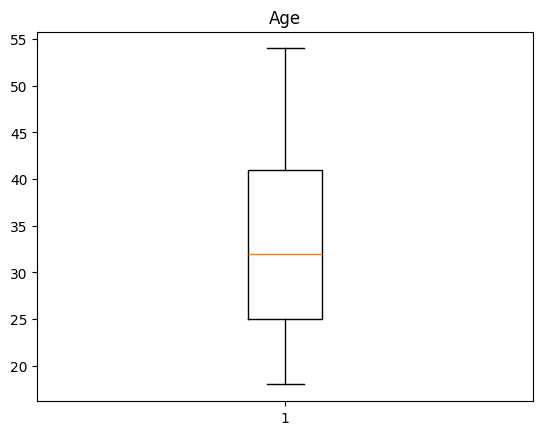

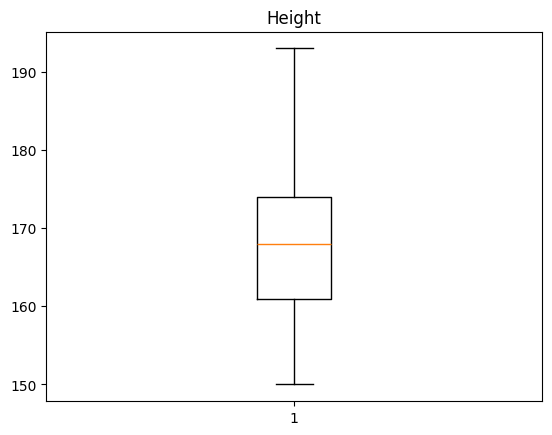

In [10]:
plt.boxplot(df["Age"])
plt.title("Age")
plt.show()

plt.boxplot(df["Height"])
plt.title("Height")
plt.show()

In [11]:
y=df["Class"]
x=df.drop("Class",axis=1)

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=0)


In [13]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1288, 14), (322, 14), (1288,), (322,))

In [14]:
scale=StandardScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [15]:
#model=Pipeline([("SVC",SVC(C=10,gamma=0.1),("KNN",KNeighborsClassifier(metric="manhatten",n_neighbors=3,weights="distance")),("rfc",RandomForestClassifier(n_estimators=200,max_depth=None,min_samples_leaf=1,min_samples_split=2)))])

In [16]:
svc=SVC(C=1.5,gamma=0.1,kernel='rbf')

In [50]:
knn=KNeighborsClassifier(metric="manhattan",n_neighbors=6,weights="uniform")

In [18]:
svc.fit(x_train_scaled,y_train)

SVC(C=1.5, gamma=0.1)

In [38]:
rfc=RandomForestClassifier(n_estimators=300,max_depth=15,min_samples_leaf=4,min_samples_split=3)

In [51]:
knn.fit(x_train_scaled,y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=6)

In [39]:
rfc.fit(x_train,y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=4, min_samples_split=3,
                       n_estimators=300)

In [22]:
svc_pred=svc.predict(x_test_scaled)
print(svc_pred)
accuracy=accuracy_score(y_test,svc_pred)
print(accuracy)

[2 4 2 2 4 2 2 1 3 2 4 2 2 3 3 3 4 4 2 2 3 2 3 2 4 2 2 2 1 4 4 3 2 4 3 3 3
 3 3 2 2 3 4 3 1 2 2 4 2 3 4 2 3 3 3 2 4 2 2 3 3 3 2 4 3 3 3 4 2 2 2 4 2 3
 3 2 2 4 3 2 3 4 2 2 2 3 4 2 2 1 4 2 1 3 3 2 4 2 3 3 4 3 3 3 3 2 4 1 2 4 2
 2 2 3 3 2 2 3 2 3 2 3 4 2 4 2 2 3 3 3 3 2 4 3 2 2 2 3 2 3 3 2 4 4 2 2 4 2
 3 2 2 3 2 3 3 2 3 2 3 1 2 3 3 4 2 3 3 3 3 2 3 4 2 3 3 2 2 3 4 2 4 4 4 3 3
 3 3 4 2 2 3 2 2 2 2 2 3 4 3 4 2 3 3 4 2 4 3 2 3 2 3 2 2 4 4 2 2 4 2 2 2 3
 3 2 3 3 2 2 1 4 3 4 2 2 2 3 3 2 3 4 2 2 3 3 2 3 4 3 3 3 1 3 4 2 2 2 2 3 3
 4 2 3 3 2 4 3 3 2 3 2 4 4 3 4 4 2 3 2 3 4 3 2 2 2 2 4 3 3 3 3 1 3 3 2 2 3
 2 3 1 3 4 2 2 3 3 4 2 2 3 2 2 4 2 4 4 3 2 2 3 2 3 2]
0.7888198757763976


In [53]:
knn_pred=knn.predict(x_test_scaled)
print(knn_pred)
accuracy=accuracy_score(y_test,knn_pred)
print(accuracy)

[2 4 2 2 4 2 2 1 3 2 4 2 2 3 3 3 4 4 2 2 3 2 3 2 4 2 2 2 1 3 4 3 2 3 3 3 3
 3 3 2 2 3 4 3 1 3 2 4 3 2 4 2 3 2 3 2 3 2 2 3 2 3 2 4 2 3 3 3 2 2 2 4 3 3
 3 2 2 4 3 2 3 2 2 2 1 3 4 2 2 1 4 2 1 3 3 2 3 2 3 2 4 3 3 3 2 2 3 1 2 3 2
 2 2 3 3 3 2 3 2 2 2 3 3 2 3 2 2 3 3 2 3 2 4 2 3 3 2 3 2 3 3 2 4 3 2 2 3 2
 3 2 2 3 2 3 3 2 3 2 2 2 2 3 3 3 2 3 2 3 3 2 3 4 2 3 2 2 2 3 4 2 4 4 3 3 3
 2 3 4 2 2 2 3 2 2 2 3 3 4 4 4 2 3 3 4 2 4 3 1 4 2 3 2 2 4 2 2 2 4 2 2 2 2
 2 2 3 3 2 2 1 4 3 3 2 2 2 3 2 2 3 3 2 2 3 3 2 3 4 3 3 3 1 3 4 2 2 2 2 3 3
 4 2 3 3 2 4 3 3 2 2 2 3 3 3 4 4 2 3 2 3 4 3 2 2 2 2 2 3 3 3 3 1 3 4 2 2 3
 2 3 1 3 4 2 2 3 3 2 2 2 3 2 2 3 2 4 4 3 2 2 3 2 2 2]
0.7422360248447205


In [40]:
rfc_pred=rfc.predict(x_test)
print(rfc_pred)
accuracy=accuracy_score(y_test,rfc_pred)
print(accuracy)

[2 4 2 2 4 2 2 2 3 2 4 2 2 3 3 3 3 3 2 2 3 2 3 2 4 3 3 2 1 3 4 3 2 4 3 3 3
 3 4 2 2 3 4 3 2 2 2 4 3 3 4 2 3 2 3 2 3 2 2 3 2 3 2 4 3 3 3 4 2 2 2 3 2 3
 2 2 2 4 2 2 3 4 2 2 3 3 4 2 2 1 4 2 2 3 3 2 4 2 3 2 4 2 3 3 2 2 4 1 2 3 2
 2 2 3 3 2 2 3 2 3 2 3 4 2 3 2 2 3 3 2 3 2 4 3 3 2 2 3 2 3 3 2 4 3 3 2 4 3
 3 2 2 3 2 3 3 3 3 2 3 2 2 3 3 3 2 3 2 2 3 2 3 4 2 3 3 2 2 3 4 2 3 4 3 3 3
 3 4 4 2 2 3 3 2 2 2 2 3 4 3 4 2 3 2 4 2 4 3 2 3 2 3 2 2 4 2 2 2 4 2 2 2 3
 3 2 3 2 2 2 1 4 3 4 2 2 2 3 3 2 3 4 2 2 3 3 2 3 4 3 3 3 3 3 4 2 2 2 2 4 3
 4 2 3 3 2 4 3 3 2 3 2 4 3 3 4 4 2 3 2 3 4 3 2 2 2 2 4 3 3 3 3 2 3 4 2 2 3
 2 3 1 3 4 2 2 3 3 2 2 3 3 2 2 4 2 4 4 3 2 2 3 2 2 2]
0.7795031055900621


In [25]:
train_acc=svc.score(x_train_scaled,y_train)
test_acc=svc.score(x_test_scaled,y_test)
print(train_acc)
print(test_acc)

0.8982919254658385
0.7888198757763976


In [41]:
rfc_train_acc=rfc.score(x_train,y_train)
rfc_test_acc=rfc.score(x_test,y_test)
print(rfc_train_acc)
print(rfc_test_acc)

0.8874223602484472
0.7795031055900621


In [54]:
knn_train_acc=knn.score(x_train_scaled,y_train)
knn_test_acc=knn.score(x_test_scaled,y_test)
print(knn_train_acc)
print(knn_test_acc)

0.8090062111801242
0.7422360248447205


In [67]:
from tensorflow import keras

model = keras.models.Sequential()

model.add(keras.layers.Input(shape=(14,)))

model.add(keras.layers.Dense(
    64,
    activation='relu',
    kernel_initializer='he_normal'
))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.1))

model.add(keras.layers.Dense(
    32,
    activation='relu',
    kernel_initializer='he_normal'
))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dropout(0.1))

model.add(keras.layers.Dense(
    4,
    activation='softmax'
))

In [68]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [70]:
ann_model=model.fit(x_train_scaled,y_train - 1,epochs=94,validation_data=(x_test_scaled,y_test - 1))

Epoch 1/94
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7974 - loss: 0.5076 - val_accuracy: 0.7516 - val_loss: 0.5421
Epoch 2/94
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7873 - loss: 0.5254 - val_accuracy: 0.7578 - val_loss: 0.5408
Epoch 3/94
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7842 - loss: 0.5058 - val_accuracy: 0.7516 - val_loss: 0.5406
Epoch 4/94
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7873 - loss: 0.5041 - val_accuracy: 0.7516 - val_loss: 0.5397
Epoch 5/94
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7865 - loss: 0.5121 - val_accuracy: 0.7609 - val_loss: 0.5393
Epoch 6/94
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7787 - loss: 0.5154 - val_accuracy: 0.7547 - val_loss: 0.5394
Epoch 7/94
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7943 - loss: 0.5111 - val_accuracy: 0.7547 - val_loss: 0.5408
Epoch 8/94
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7857 - loss: 0.5275 - val_accuracy: 0.7547 - val

In [72]:
#from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svc_pred)
print(cm)

[[  8   5   0   2]
 [  2 107  21   2]
 [  0  17  91  10]
 [  1   1   7  48]]


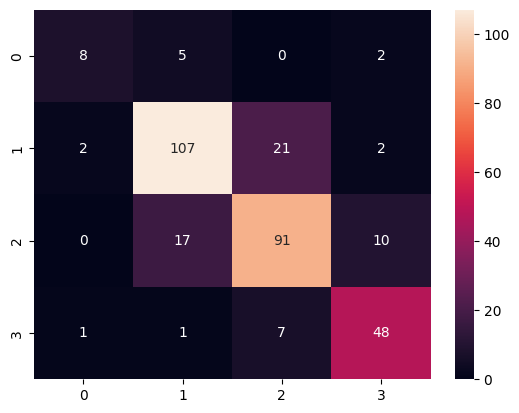

In [74]:


sns.heatmap(cm, annot=True, fmt='d')
plt.show()

[[  9   4   2   0]
 [  1 112  19   0]
 [  1  24  84   9]
 [  1   4  18  34]]


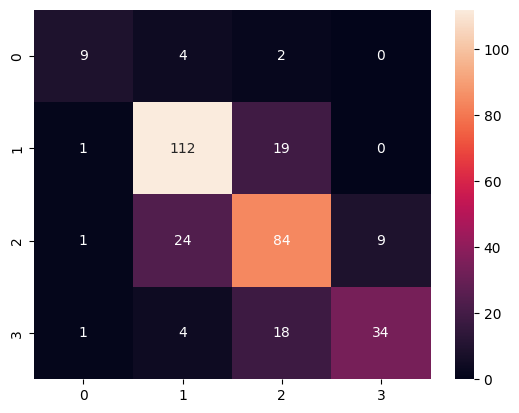

In [75]:
cm1= confusion_matrix(y_test, knn_pred)
print(cm1)


sns.heatmap(cm1, annot=True, fmt='d')
plt.show()

[[  9   4   2   0]
 [  1 112  19   0]
 [  1  24  84   9]
 [  1   4  18  34]]


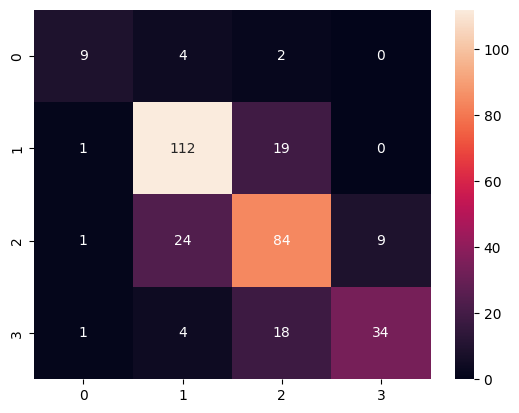

In [76]:
cm2= confusion_matrix(y_test, rfc_pred)
print(cm1)


sns.heatmap(cm1, annot=True, fmt='d')
plt.show()

In [77]:
new_person = [[
    25,     # Age
    1.75,   # Height
    78,     # Weight
    3,      # FCVC
    3,      # NCP
    2,      # CH2O
    2,      # FAF
    1,
    0,
    1,
    0,
    1,
    0,
    1
]]

In [79]:
new_person_scaled = scale.fit_transform(new_person)

prediction = model.predict(new_person_scaled)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
[[0.00907906 0.17633235 0.8005667  0.01402184]]
